# Seasonal Agriculture Performance Analysis

**Program:** VOIS for Tech — AICTE Internship, Batch 1 (2026–2027)
**Type:** Major Project — Data Analytics
**Author:** Data Analytics Intern
**Submission Deadline:** 10 September 2026

---

## 1. Introduction

The main question behind this project is straightforward: **does the season actually affect farm performance?**

Agricultural conditions change across **Kharif, Rabi and Zaid**. Rainfall, temperature, humidity, soil conditions, water usage and farming inputs are different in each season, and these differences can affect yield, resource efficiency, cost and profit.

Instead of relying on assumptions or looking at individual records, this project uses **data cleaning, exploratory data analysis and statistical testing** to identify measurable seasonal patterns in the data.

The dataset contains **4,000 farm records** covering 8 Indian states, 8 crops and 3 seasons. It includes environmental conditions, farming inputs and farm-level economic measures such as **cost, revenue, profit and water usage**.

---

## 2. Problem Statement

**The problem is to analyze the dataset and determine how farm performance changes across Kharif, Rabi and Zaid by examining measurable differences in climate conditions, yield, resource efficiency, profitability and crop-health risk.**

---

## 3. Objective

The objective of this project is to turn the raw agricultural data into **clear, evidence-backed insights** by:

* Understanding and cleaning the dataset
* Performing univariate, bivariate and multivariate analysis
* Comparing yield, profitability and water-use efficiency across seasons
* Using statistical tests to determine whether observed seasonal differences are significant
* Identifying five key results and converting them into practical recommendations

---

## 4. Key Analytical Questions

The analysis focuses on five questions:

1. How do rainfall, temperature, humidity and soil moisture differ across Kharif, Rabi and Zaid?
2. Does yield and water-use efficiency change across the three seasons?
3. How does average farm profit change from one season to another?
4. Does the proportion of loss-making farms increase across seasons?
5. Is disease/pest risk related to rainfall, and which season carries the highest crop-health risk?

The analysis follows these questions step by step. **The purpose is not just to generate charts, but to use the data to understand what is actually changing across seasons and why those differences matter.**

## 5. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)


## 6. Loading the Dataset

In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()


   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   

   Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_pH  \
0        486.4               24.3          69.1                 5.8     7.14   
1        855.4               25.7          78.4                 5.1     5.20   
2        455.6               23.9          56.4                10.3     5.82   
3        753.2               29.7          65.2                 6.3     5.98   
4        101.6               34.1          55.2                 6.5     6.90   

   Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  Potass

In [ ]:
df.tail()


      Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
3995  SF13996       Karnataka    Rajkot   Wheat  Kharif                4.72   
3996  SF13997       Karnataka   Krishna  Chilli  Kharif                8.77   
3997  SF13998  Andhra Pradesh     Erode  Pulses    Zaid               10.47   
3998  SF13999          Punjab  Warangal  Cotton  Kharif                1.73   
3999  SF14000          Punjab    Nashik   Wheat  Kharif                3.31   

      Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
3995        865.4               27.3          51.4                 6.3   
3996        947.5               29.2          85.5                 6.1   
3997         80.0               35.4          68.5                 8.6   
3998        475.0               28.2          61.7                 6.4   
3999        984.3               25.8          77.2                 5.9   

      Soil_pH  Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  \
3995     7

## 7. Dataset Understanding

### Shape

In [ ]:
print("Rows, Columns:", df.shape)


Rows, Columns: (4000, 28)


### Columns

In [ ]:
print(list(df.columns))


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


### Structure & Data Types

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

### Statistical Summary

In [ ]:
df.describe().T


                                count           mean            std  \
Farm_Area_Hectares             4000.0       7.888265       4.223764   
Rainfall_mm                    3952.0     601.152657     288.925025   
Avg_Temperature_C              4000.0      26.818900       3.818180   
Humidity_pct                   4000.0      63.210500      11.960834   
Sunlight_Hours_Day             4000.0       7.323050       1.121186   
Soil_pH                        4000.0       6.701010       0.641461   
Soil_Moisture_pct              3960.0      26.508232       6.712484   
Nitrogen_kg_ha                 4000.0     120.250825      31.216452   
Phosphorus_kg_ha               4000.0      57.781850      17.015074   
Potassium_kg_ha                4000.0     104.760050      27.742681   
Fertilizer_kg_ha               4000.0     186.036000      60.260583   
Pesticide_Litre_ha             4000.0       5.070935       1.978879   
Seed_Quality_Score             4000.0       0.826138       0.101747   
Yield_

**Observation:** The dataset contains 28 columns covering location, crop and season details, environmental readings, farming inputs and farm economics. Most numeric fields are complete, while `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` contain missing values.

This gives us a clear cleaning task before starting the actual analysis: handle the missing values without destroying seasonal differences.


## 8. Missing Value Analysis

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Farm_IDs: 0


**Observation:** `Rainfall_mm` has 48 missing values, `Soil_Moisture_pct` has 40 and `Yield_Tonnes_Ha` has 32. These are small gaps compared with the full dataset. There are also no duplicate rows or duplicate `Farm_ID` values.

The important point is that these missing values are in season-sensitive variables, so filling them with one global value could distort the comparisons later.


## 9. Data Cleaning

Before calculating insights, the dataset needs to be made consistent.

For the three numeric columns with missing values, I used the **median within each season** instead of one global median. This keeps the imputation aligned with the seasonal conditions being studied.

For example, replacing a missing Kharif rainfall value with the overall rainfall median could make that record look less like Kharif. Season-wise median imputation is a more suitable choice for this analysis.


In [ ]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [ ]:
# Standardize categorical text columns
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    df[col] = df[col].astype(str).str.strip()

df['Season'] = pd.Categorical(df['Season'], categories=['Kharif', 'Rabi', 'Zaid'], ordered=True)
print(df['Season'].cat.categories.tolist())


['Kharif', 'Rabi', 'Zaid']


### Derived Metrics

In [ ]:
# Profit margin (%) and a simple loss flag, used throughout the seasonal analysis
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Is_Loss'] = df['Profit_INR'] < 0

df[['Profit_INR', 'Revenue_INR', 'Profit_Margin_pct', 'Is_Loss']].head()


   Profit_INR  Revenue_INR  Profit_Margin_pct  Is_Loss
0      -11852        30810         -38.468030     True
1     -451950        40401       -1118.660429     True
2     -124744       190466         -65.494104     True
3      -95704       200740         -47.675600     True
4     -144352       193607         -74.559288     True

## 10. Univariate Analysis

I start by examining **one variable at a time** to understand the basic characteristics of the dataset before moving into seasonal comparisons and relationships between variables.

This helps identify the **typical range, distribution, skewness and unusual values** in individual variables, giving a clearer understanding of the data before drawing further conclusions.


#### Record count by season

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


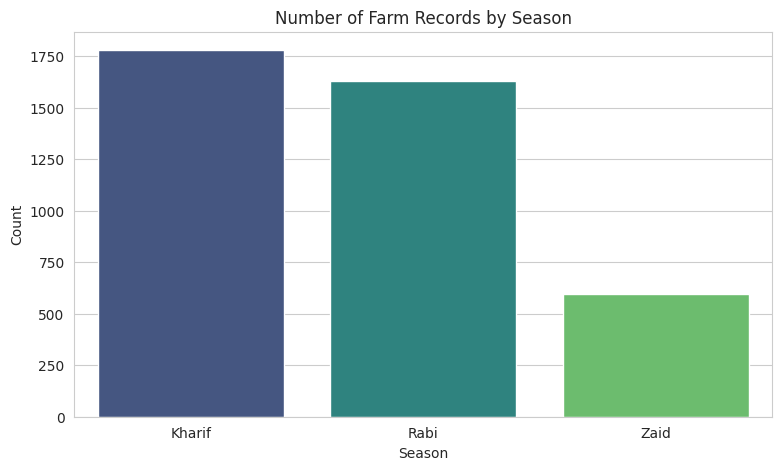

In [ ]:
season_counts = df['Season'].value_counts().reindex(['Kharif', 'Rabi', 'Zaid'])
print(season_counts)

plt.figure()
sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis')
plt.title('Number of Farm Records by Season')
plt.xlabel('Season'); plt.ylabel('Count')
plt.show()


#### Distribution of Yield

count    4000.000000
mean        5.241955
std        13.311661
min         0.300000
25%         1.050000
50%         1.730000
75%         2.830000
max       101.440000
Name: Yield_Tonnes_Ha, dtype: float64


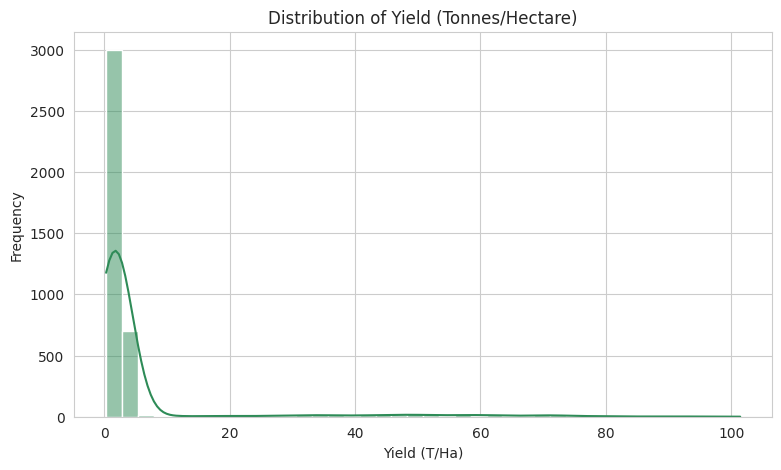

In [ ]:
plt.figure()
sns.histplot(df['Yield_Tonnes_Ha'], bins=40, kde=True, color='seagreen')
plt.title('Distribution of Yield (Tonnes/Hectare)')
plt.xlabel('Yield (T/Ha)'); plt.ylabel('Frequency')
plt.show()

print(df['Yield_Tonnes_Ha'].describe())


**Observation:** Yield is heavily right-skewed. The maximum is around 101 T/Ha, while the median is around 1.7 T/Ha. That large gap tells us that a few extreme values can pull the mean upward.

Because of this, the median is used later for seasonal yield comparison. It gives a more stable view of the typical farm than the mean in this dataset.


#### Distribution of Profit

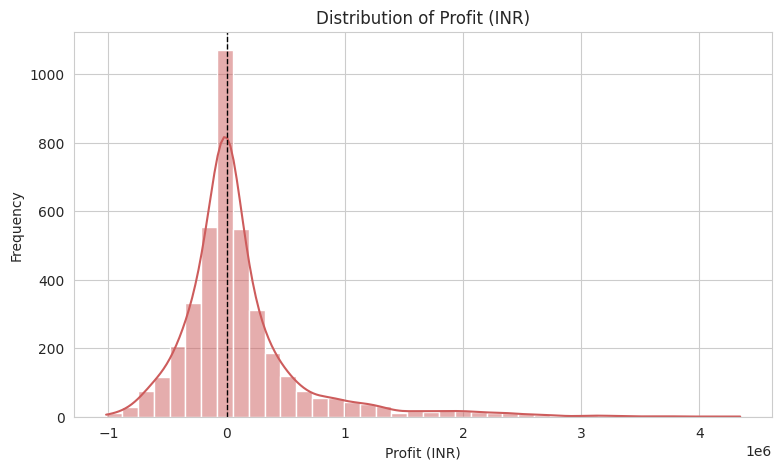

In [ ]:
plt.figure()
sns.histplot(df['Profit_INR'], bins=40, kde=True, color='indianred')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Distribution of Profit (INR)')
plt.xlabel('Profit (INR)'); plt.ylabel('Frequency')
plt.show()


**Observation:** A noticeable part of the profit distribution is below ₹0, meaning loss-making farms are not rare exceptions in this dataset. This makes profitability more useful to investigate than yield alone.


## 11. Bivariate Analysis

I now move from analyzing individual variables to **examining two variables together**. This helps identify how farm performance changes with season and whether meaningful relationships exist between different numeric variables.

At this stage, the analysis moves beyond basic data understanding and starts showing **measurable differences, trends and relationships** within the dataset.


#### Yield by Season

Season
Kharif    1.95
Rabi      1.66
Zaid      1.45
Name: Yield_Tonnes_Ha, dtype: float64


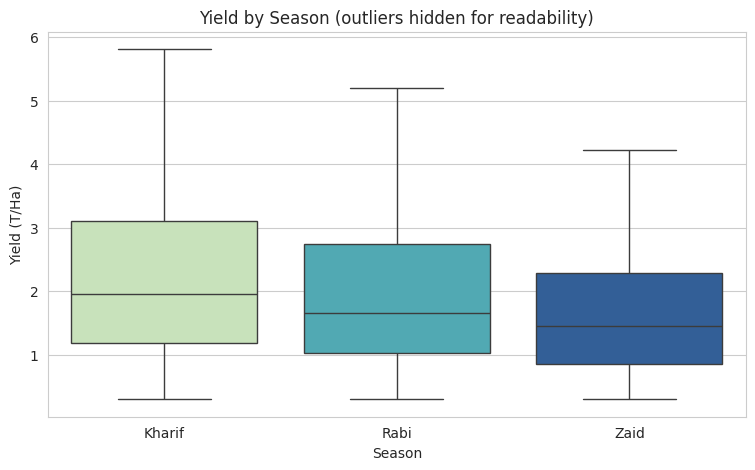

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='YlGnBu', showfliers=False)
plt.title('Yield by Season (outliers hidden for readability)')
plt.xlabel('Season'); plt.ylabel('Yield (T/Ha)')
plt.show()

print(df.groupby('Season')['Yield_Tonnes_Ha'].median())


#### Profit by Season

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


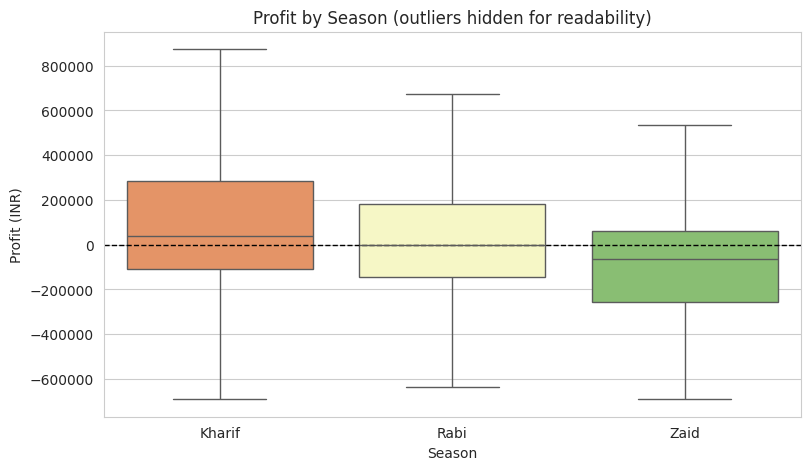

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Season', y='Profit_INR', palette='RdYlGn', showfliers=False)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Profit by Season (outliers hidden for readability)')
plt.xlabel('Season'); plt.ylabel('Profit (INR)')
plt.show()

print(df.groupby('Season')['Profit_INR'].mean())


#### Rainfall vs Yield

Correlation: 0.029


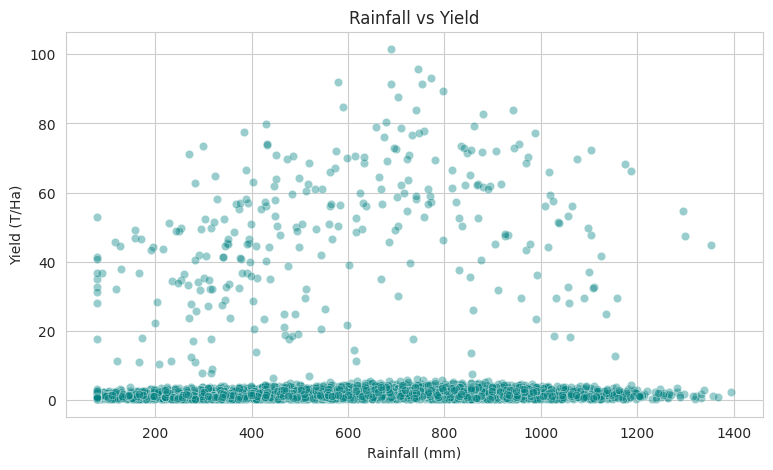

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.4, color='teal')
plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)'); plt.ylabel('Yield (T/Ha)')
plt.show()

print("Correlation:", round(df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha']), 3))


#### Correlation Heatmap (numeric variables)

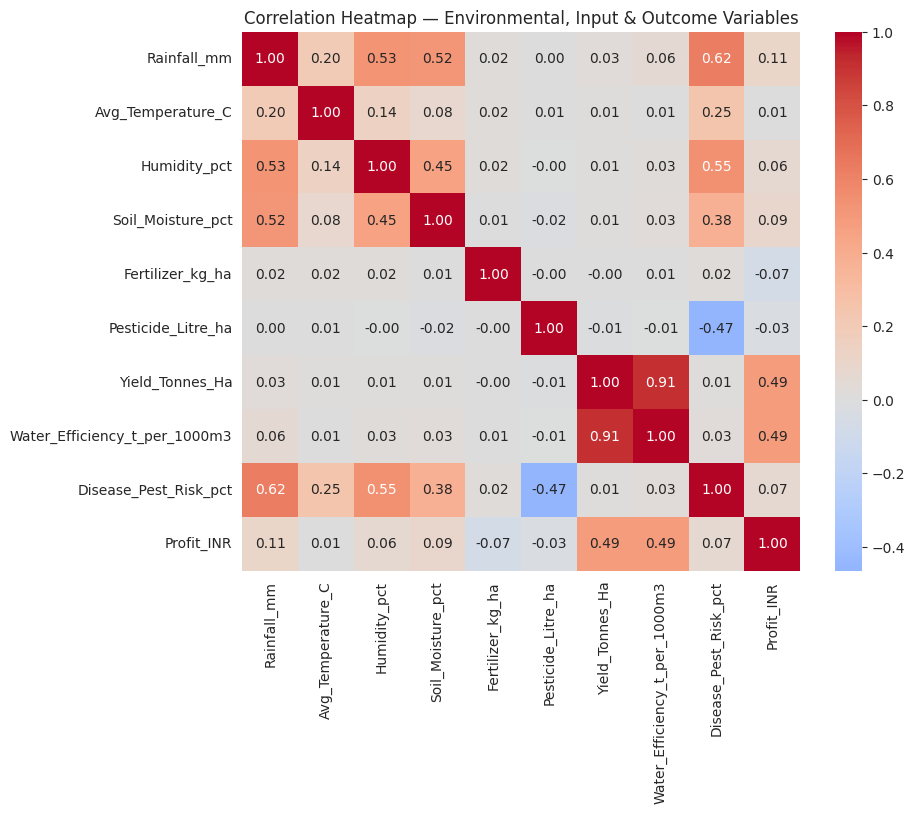

In [ ]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Yield_Tonnes_Ha',
             'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Profit_INR']

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Environmental, Input & Outcome Variables')
plt.show()


**Observation:** `Rainfall_mm` has a strong positive correlation with `Disease_Pest_Risk_pct` (r ≈ 0.63). However, yield and profit do not show a strong linear relationship with one environmental variable alone.

That suggests farm outcomes are influenced by a combination of conditions and inputs. This is why a seasonal and multivariate view is more useful than relying on one correlation.


## 12. Multivariate Analysis

Farm performance is influenced by **multiple factors at the same time**. Season, rainfall, disease risk, water-use efficiency and crop choice can interact, so looking at them individually may not show the complete picture.

This section brings **three or more variables together** to identify combined patterns and trade-offs that may not be visible through simpler one- or two-variable analysis.


#### Rainfall vs Yield, coloured by Season

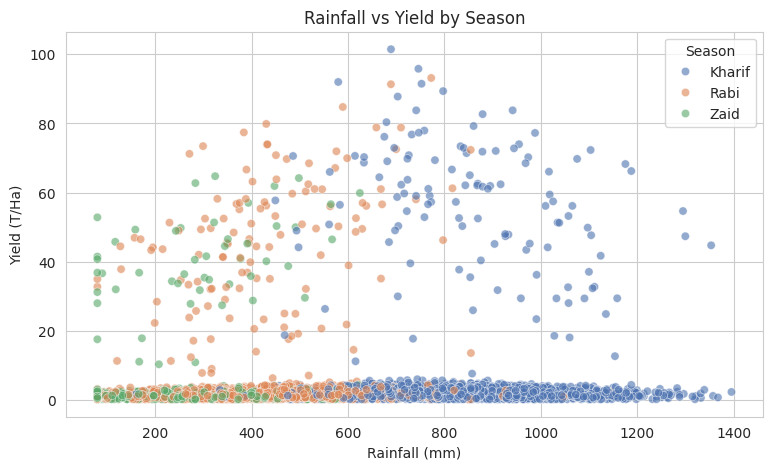

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season',
                 palette='deep', alpha=0.6)
plt.title('Rainfall vs Yield by Season')
plt.xlabel('Rainfall (mm)'); plt.ylabel('Yield (T/Ha)')
plt.show()


#### Average Profit by Season and Crop

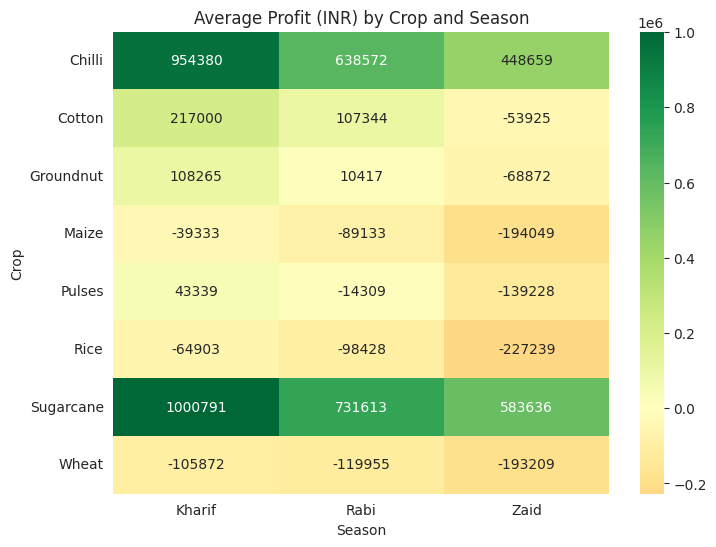

In [ ]:
profit_pivot = df.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(profit_pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by Crop and Season')
plt.show()


#### Water Efficiency vs Disease Risk, by Season

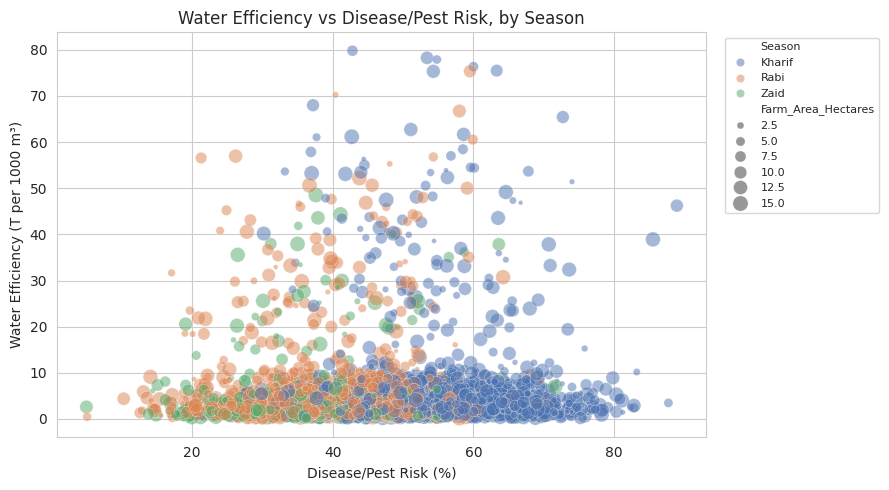

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Water_Efficiency_t_per_1000m3',
                 hue='Season', size='Farm_Area_Hectares', sizes=(10, 120), alpha=0.5, palette='deep')
plt.title('Water Efficiency vs Disease/Pest Risk, by Season')
plt.xlabel('Disease/Pest Risk (%)'); plt.ylabel('Water Efficiency (T per 1000 m³)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** Kharif farms appear in the higher-rainfall and higher-disease/pest-risk region at the same time. They also show the highest water efficiency.

So Kharif is not simply the “best” season in every way. It offers stronger performance, but it also brings higher crop-health risk. That trade-off becomes important for recommendations.


## 13. Statistical Analysis

The charts show clear differences across seasons, but **a visible difference does not automatically mean the difference is statistically meaningful**. Statistical testing is used to check whether the observed seasonal differences are likely to reflect real differences in the data rather than random variation.

The analysis uses:

* **Yield:** Kruskal–Wallis test, since yield is heavily skewed and contains extreme values.
* **Profit, Water Efficiency and Disease/Pest Risk:** One-way ANOVA, to test whether their seasonal means differ significantly.


In [ ]:
results = {}

# Kruskal-Wallis for Yield (robust to the outliers/skew seen earlier)
groups_yield = [df[df['Season'] == s]['Yield_Tonnes_Ha'] for s in ['Kharif', 'Rabi', 'Zaid']]
h, p_yield = stats.kruskal(*groups_yield)
results['Yield (Kruskal-Wallis)'] = (round(h, 2), p_yield)

# One-way ANOVA for the rest
for col, label in [('Profit_INR', 'Profit'),
                    ('Water_Efficiency_t_per_1000m3', 'Water Efficiency'),
                    ('Disease_Pest_Risk_pct', 'Disease/Pest Risk')]:
    groups = [df[df['Season'] == s][col] for s in ['Kharif', 'Rabi', 'Zaid']]
    f, p = stats.f_oneway(*groups)
    results[f'{label} (ANOVA)'] = (round(f, 2), p)

for k, (stat_val, p_val) in results.items():
    sig = "significant" if p_val < 0.05 else "not significant"
    print(f"{k:32s} stat={stat_val:>10}   p={p_val:.2e}   -> {sig}")


Yield (Kruskal-Wallis)           stat=     70.17   p=5.80e-16   -> significant
Profit (ANOVA)                   stat=     34.29   p=1.71e-15   -> significant
Water Efficiency (ANOVA)         stat=      6.95   p=9.72e-04   -> significant
Disease/Pest Risk (ANOVA)        stat=   1049.47   p=0.00e+00   -> significant


**Observation:** All four tested metrics show statistically significant differences across seasons at p < 0.05.

In practical terms, the seasonal patterns seen in the charts are supported by the statistical tests. The next section turns those results into five clear findings.


---
## 14. Five Key Results

After cleaning the data, exploring the variables and testing the seasonal differences, I selected five results that directly answer the project questions.

Each result below connects a measurable observation with what it means for agricultural performance.


### Result 1 — Kharif is the wettest & most humid season; Zaid is the hottest & driest

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Soil_Moisture_pct
Season                                                                 
Kharif        852.1               28.5          71.8               31.2
Rabi          435.9               23.5          57.9               24.1
Zaid          299.1               31.0          52.0               19.2


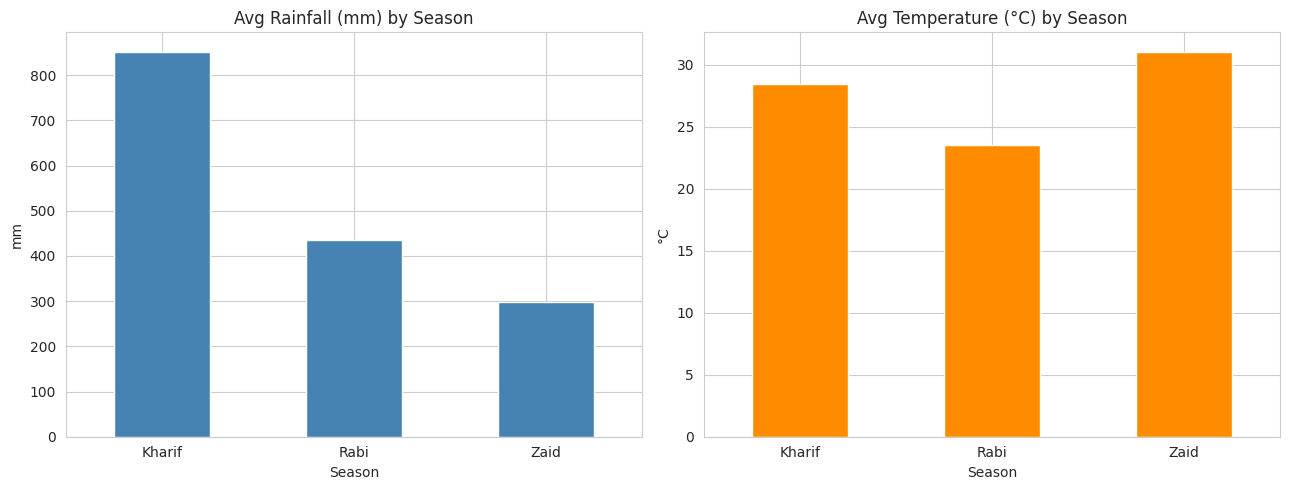

In [ ]:
season_climate = df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C',
                                        'Humidity_pct', 'Soil_Moisture_pct']].mean()
print(season_climate.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
season_climate['Rainfall_mm'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Rainfall (mm) by Season'); axes[0].set_ylabel('mm'); axes[0].tick_params(axis='x', rotation=0)

season_climate['Avg_Temperature_C'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Avg Temperature (°C) by Season'); axes[1].set_ylabel('°C'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Result:** Kharif averages around 852 mm rainfall and 72% humidity, while Zaid averages around 299 mm rainfall and 52% humidity. Zaid is also the hottest season, at approximately 31.0°C on average.

This confirms that the three seasons represent different growing environments. These climate differences provide the context for the yield, water-use and profit patterns that follow.


### Result 2 — Median yield and water-use efficiency both fall from Kharif → Rabi → Zaid

        Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3
Season                                                
Kharif             1.95                           3.28
Rabi               1.66                           2.74
Zaid               1.45                           2.30


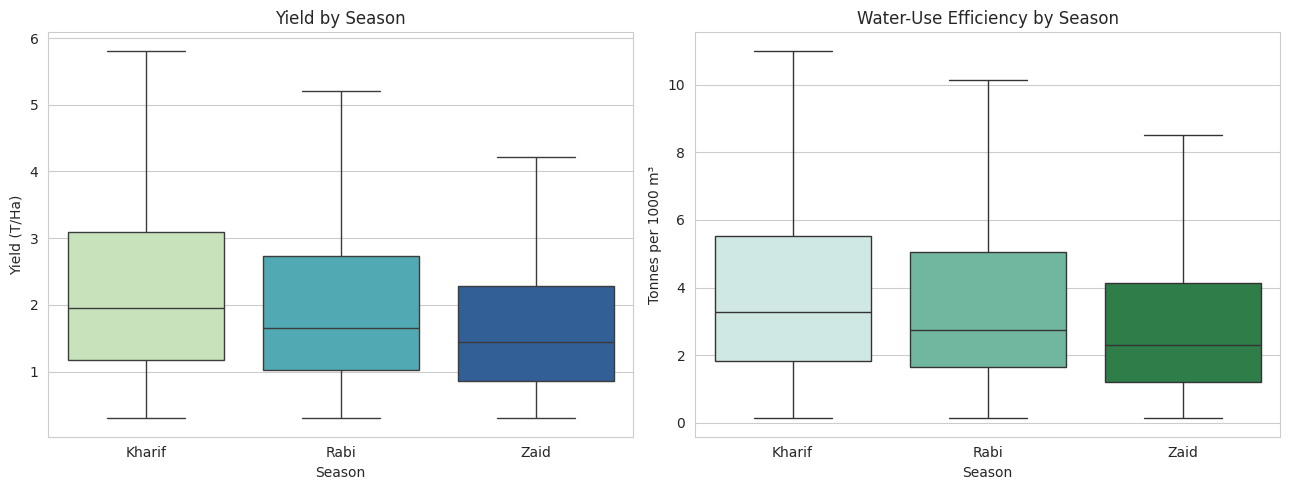

In [ ]:
yield_wue = df.groupby('Season')[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']].median()
print(yield_wue.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='YlGnBu', showfliers=False)
axes[0].set_title('Yield by Season'); axes[0].set_ylabel('Yield (T/Ha)')

sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1], palette='BuGn', showfliers=False)
axes[1].set_title('Water-Use Efficiency by Season'); axes[1].set_ylabel('Tonnes per 1000 m³')

plt.tight_layout()
plt.show()


**Result:** Median yield falls from **1.95 T/Ha in Kharif** to **1.66 T/Ha in Rabi** and **1.45 T/Ha in Zaid**. The Kruskal–Wallis test shows that this difference is statistically significant (p < 0.001).

Water-use efficiency follows the same order: Kharif is highest and Zaid is lowest. In this dataset, Zaid farms are getting less output per hectare and per unit of water.


### Result 3 — Average profit swings from a gain in Kharif to a net loss in Zaid

Season
Kharif    178915.0
Rabi       87689.0
Zaid      -24805.0
Name: Profit_INR, dtype: float64


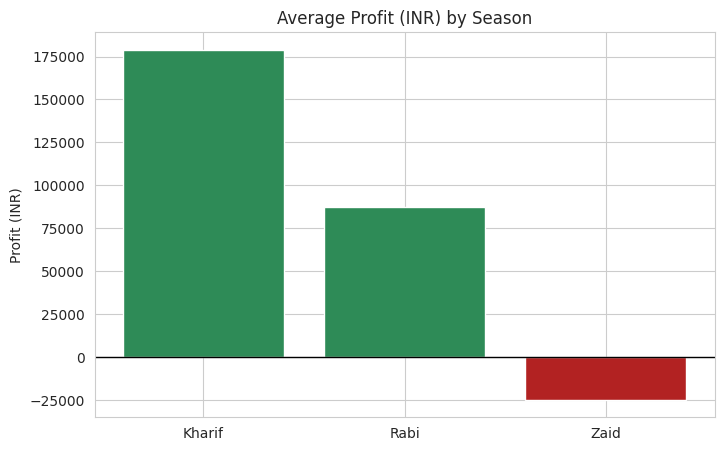

In [ ]:
profit_by_season = df.groupby('Season')['Profit_INR'].mean()
print(profit_by_season.round(0))

plt.figure(figsize=(8, 5))
colors = ['seagreen' if v >= 0 else 'firebrick' for v in profit_by_season.values]
plt.bar(profit_by_season.index.astype(str), profit_by_season.values, color=colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Average Profit (INR) by Season')
plt.ylabel('Profit (INR)')
plt.show()


**Result:** Average profit drops from **+₹1,78,915 in Kharif** to **+₹87,689 in Rabi**, and then reaches a **net average loss of -₹24,805 in Zaid** (ANOVA p < 0.001).

Zaid is the only season where the average farm loses money. This is a stronger business signal than yield alone because it connects agricultural output with actual economic performance.


### Result 4 — The share of loss-making farms nearly doubles from Kharif to Zaid

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Loss, dtype: float64


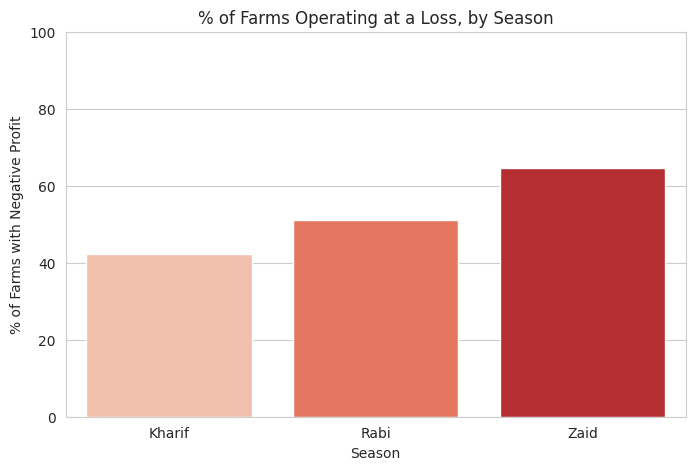

In [ ]:
loss_share = df.groupby('Season')['Is_Loss'].mean() * 100
print(loss_share.round(1))

plt.figure(figsize=(8, 5))
sns.barplot(x=loss_share.index.astype(str), y=loss_share.values, palette='Reds')
plt.title('% of Farms Operating at a Loss, by Season')
plt.ylabel('% of Farms with Negative Profit')
plt.ylim(0, 100)
plt.show()


**Result:** The share of loss-making farms increases from **42.2% in Kharif** to **51.1% in Rabi** and **64.5% in Zaid**.

This shows that the issue is not limited to a few unusual farms. By Zaid, loss-making farms form the majority of the dataset's records for that season.


### Result 5 — Disease/pest risk tracks rainfall and peaks in the wet Kharif season

Season
Kharif    54.5
Rabi      40.5
Zaid      38.2
Name: Disease_Pest_Risk_pct, dtype: float64
Correlation (Rainfall vs Disease/Pest Risk): 0.624


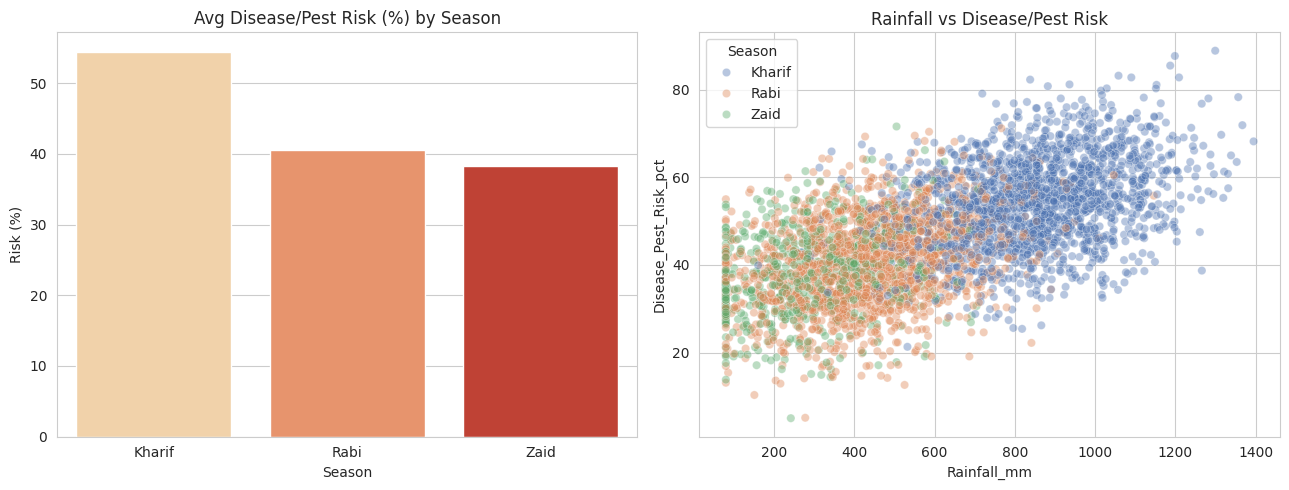

In [ ]:
risk_by_season = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()
corr_rain_risk = df['Rainfall_mm'].corr(df['Disease_Pest_Risk_pct'])
print(risk_by_season.round(1))
print("Correlation (Rainfall vs Disease/Pest Risk):", round(corr_rain_risk, 3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=risk_by_season.index.astype(str), y=risk_by_season.values, ax=axes[0], palette='OrRd')
axes[0].set_title('Avg Disease/Pest Risk (%) by Season'); axes[0].set_ylabel('Risk (%)')

sns.scatterplot(data=df, x='Rainfall_mm', y='Disease_Pest_Risk_pct', hue='Season',
                 alpha=0.4, palette='deep', ax=axes[1])
axes[1].set_title('Rainfall vs Disease/Pest Risk')

plt.tight_layout()
plt.show()


**Result:** Average disease/pest risk is **54.5% in Kharif** compared with **38.2% in Zaid**, a gap of about 16 percentage points. Rainfall and disease/pest risk also show a strong positive correlation (r ≈ 0.63).

The important learning is the trade-off: Kharif has the strongest yield and water efficiency, but it also carries the highest crop-health risk. A useful recommendation must account for both sides.


## 15. Findings

1. **Seasonal climate conditions are clearly different.** Kharif is wetter and more humid, Rabi shows moderate conditions, while Zaid is hotter and drier.

2. **Yield and water-use efficiency decline from Kharif to Zaid.** Kharif records the strongest performance on both measures, while Zaid records the lowest. Statistical testing supports that the seasonal differences are significant.

3. **Profitability becomes weaker across the seasons.** Average profit declines from Kharif to Zaid, with Zaid recording a negative average profit. At the same time, the share of loss-making farms increases from about 42% in Kharif to 65% in Zaid.

4. **Crop choice affects performance within a season.** Sugarcane and Chilli are consistently among the stronger-performing crops, while Rice, Maize and Wheat show substantial losses in Zaid.

5. **Rainfall is associated with higher crop-health risk.** Kharif has the highest rainfall as well as the highest disease/pest risk, while the positive correlation between rainfall and disease/pest risk supports a clear relationship between the two.

These findings show that **season is an important factor in agricultural performance and should be considered when making decisions about crop selection, resource use and farm planning.**

---

## 16. Conclusions

The analysis moved from raw farm records to a clearer picture of how agricultural performance changes across seasons.

**Kharif performs best on average** in terms of yield, water-use efficiency and profit, but it also carries the highest disease/pest risk. **Rabi generally falls between Kharif and Zaid**, while **Zaid performs weakest across most major metrics**, including yield, water-use efficiency and profitability.

The main conclusion from this analysis is that **agricultural performance cannot be explained by a single factor**. Season, climate conditions, resource usage and crop choice work together and can create different outcomes for farm performance.

The cleaned dataset and findings also provide a base for further analysis, particularly around **crop-season combinations, cost drivers and predictive models**.

---

## 17. Recommendations

* **Strengthen Kharif planning:** maintain its strong production potential while giving greater attention to disease and pest monitoring and preventive measures.

* **Review Zaid crop choices:** investigate whether crops showing repeated losses in Zaid should be replaced, better managed or grown under different conditions.

* **Track water-use efficiency:** use water-use efficiency as a practical performance metric instead of looking only at total water consumption.

* **Analyze crop-season combinations:** identify which crops perform best under specific seasonal and environmental conditions rather than evaluating crops independently of season.

* **Build a predictive layer:** after validating the data and relationships, a future model could estimate yield, expected profit or loss risk before the season begins.

The current project establishes the **analytical foundation** for understanding seasonal agricultural performance. The next step is to use these findings for more targeted and data-driven farm-level decisions.